In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day35-complete-case-analysis/data_science_job.csv"

df = pd.read_csv(url)

In [3]:
df.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [6]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


city_development_index , enrolled_university , education_level , experience , training_hours can be performed cca

In [8]:
cols = []
for var in df.columns:
  if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0:
    cols.append(var)

In [9]:
df[cols].sample(3)

,city_development_index,enrolled_university,education_level,experience,training_hours
3710,0.920,no_enrollment,Graduate,20.0,22.0
3949,0.924,no_enrollment,Graduate,6.0,69.0
17659,0.698,no_enrollment,Masters,16.0,8.0


**dropping the null value rows**

In [10]:
# finding out the percentage of data left in the dataset compared to original
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [12]:
new_df = df[cols].dropna()
df.shape , new_df.shape

((19158, 13), (17182, 5))

# **Checking the effects of data after performing CCA**

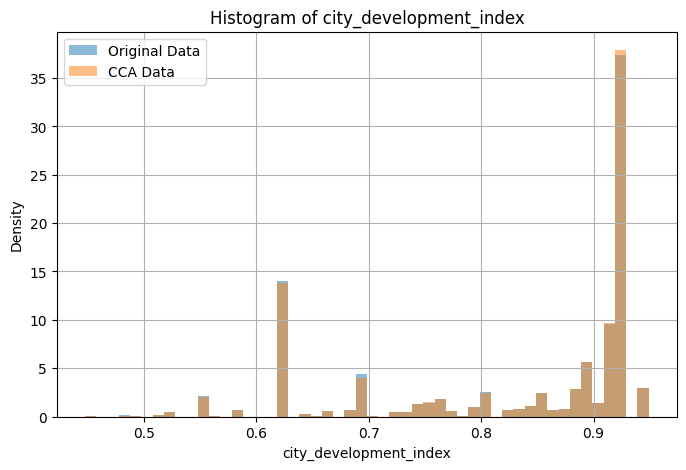

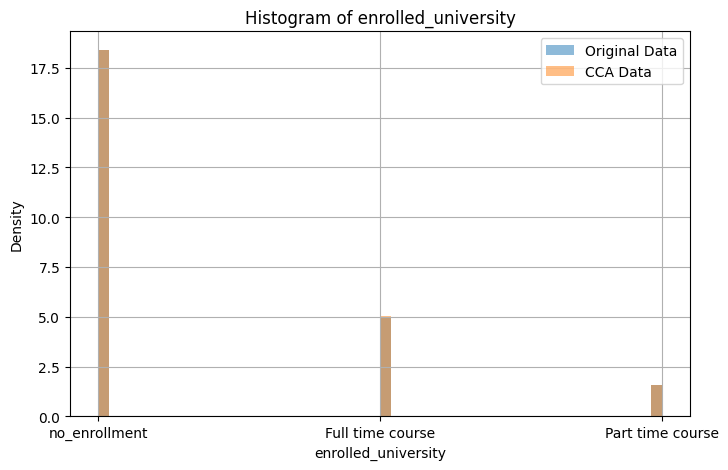

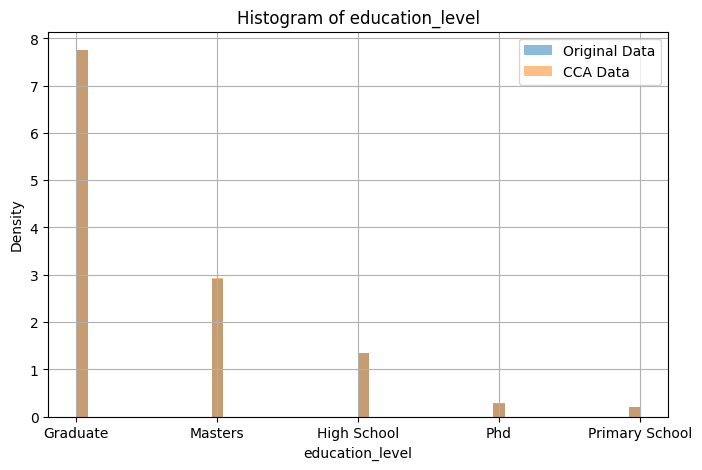

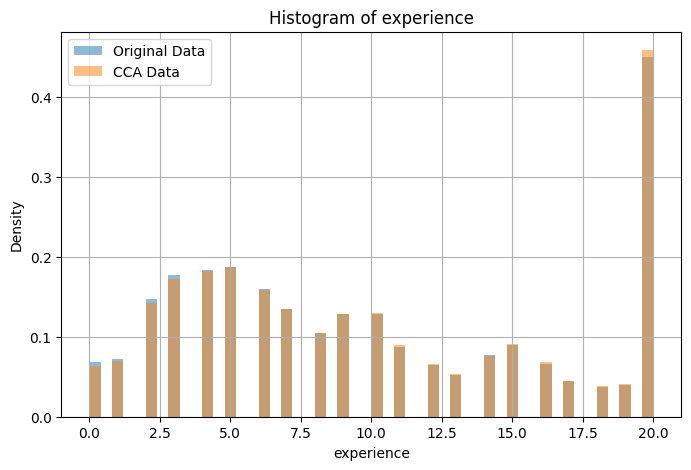

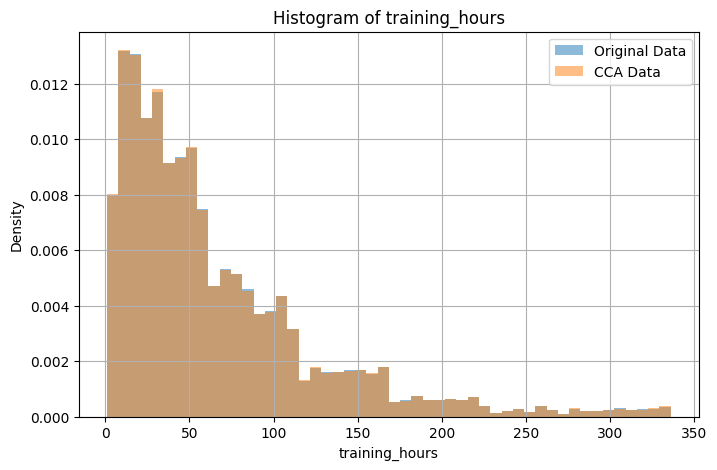

In [17]:
for col in cols:
    plt.figure(figsize=(8, 5))
    df[col].hist(bins=50, density=True, alpha=0.5, label='Original Data')
    new_df[col].hist(bins=50, density=True, alpha=0.5, label='CCA Data')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

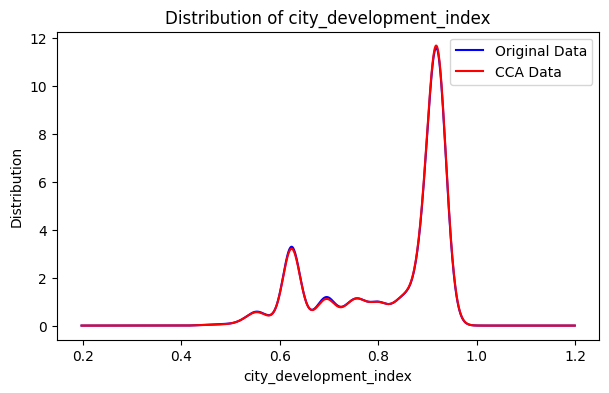

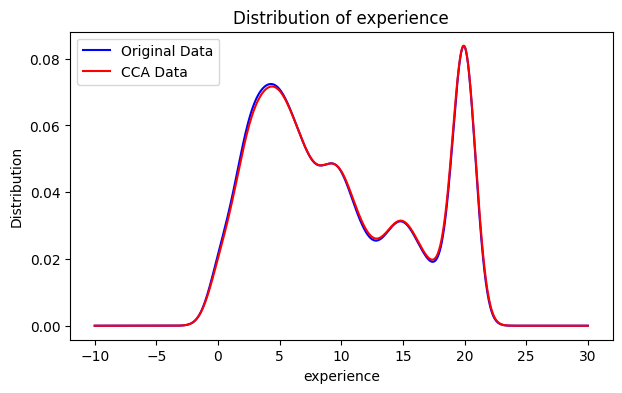

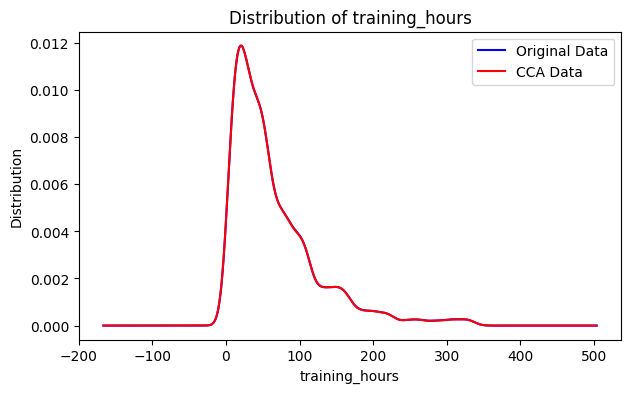

In [19]:
for col in cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        plt.figure(figsize=(7, 4))
        df[col].plot.density(color='blue', label='Original Data')
        new_df[col].plot.density(color='red', label='CCA Data')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Distribution')
        plt.legend()
        plt.show()

In [20]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [21]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
